Using device: cpu
Number of classes: 120
Found 1000 labeled images in train folder.
Train size: 800 Valid size: 200
Number of classes: 120
FinetuneResNet(
  (features): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64

/Users/kasidischuayprasert/Desktop/MachineLearning/JupyterDeepLearning/.conda/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/10 - 55.3s - Train Loss: 4.3002 Acc: 0.1275 - Val Loss: 2.8768 Acc: 0.3250
Epoch 2/10 - 53.9s - Train Loss: 2.3952 Acc: 0.4088 - Val Loss: 1.8063 Acc: 0.5250
Epoch 3/10 - 50.3s - Train Loss: 1.4945 Acc: 0.6200 - Val Loss: 1.4644 Acc: 0.6000
Epoch 4/10 - 53.5s - Train Loss: 1.2333 Acc: 0.6438 - Val Loss: 1.3993 Acc: 0.6000
Epoch 5/10 - 53.1s - Train Loss: 1.0134 Acc: 0.7375 - Val Loss: 1.4429 Acc: 0.6000
Epoch 6/10 - 52.7s - Train Loss: 0.9928 Acc: 0.7438 - Val Loss: 1.4300 Acc: 0.6450
Epoch 7/10 - 49.9s - Train Loss: 0.8388 Acc: 0.7762 - Val Loss: 1.5569 Acc: 0.6200
Epoch 8/10 - 53.2s - Train Loss: 0.9483 Acc: 0.7488 - Val Loss: 1.3744 Acc: 0.6200
Epoch 9/10 - 53.0s - Train Loss: 0.8399 Acc: 0.7738 - Val Loss: 1.3945 Acc: 0.6550
Epoch 10/10 - 50.3s - Train Loss: 0.6596 Acc: 0.8263 - Val Loss: 1.2563 Acc: 0.6400
Saved best weights to: runs/pose/train/weights/best_Dog.pt
Test Loss: 1.2563, Test Top-1 Accuracy: 0.6400


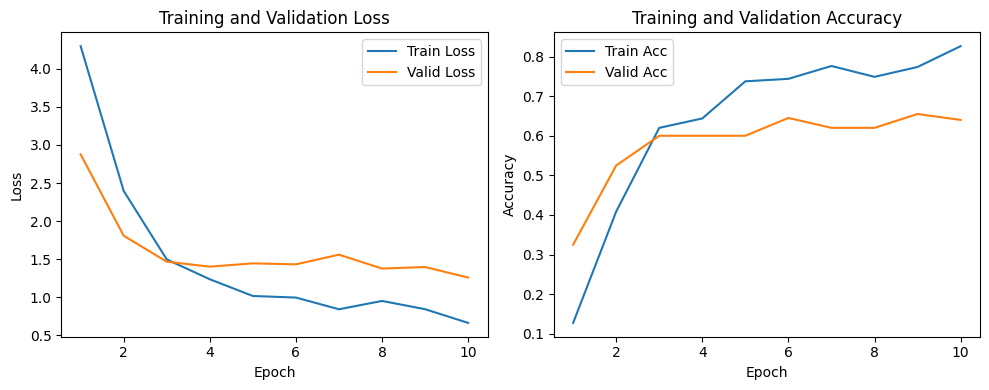

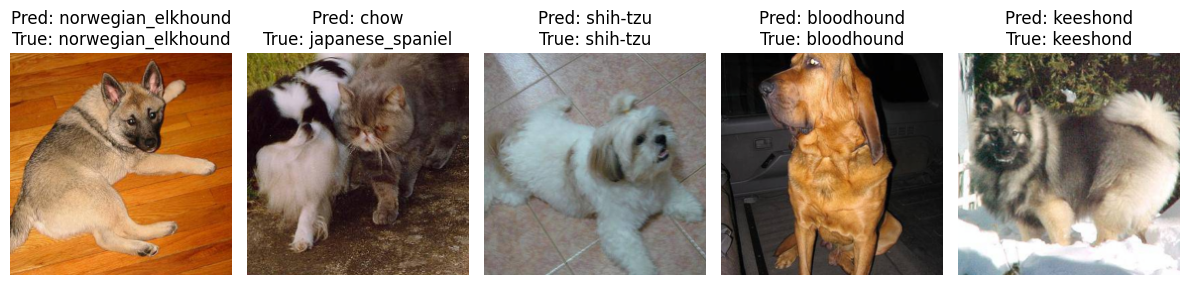

In [19]:
# ----------------------------------------------------------
# จำแนกสายพันธุ์สุนัขด้วย ResNet34 + Finetune บน Stanford Dogs (tiny)
# โค้ดนี้ทำครบตามใบงาน: เตรียมข้อมูล, สร้างโมเดล, ฝึก, ประเมิน, แสดงรูปผลลัพธ์
# พร้อมคอมเมนต์ภาษาไทยอธิบายแนวคิด/สมการแต่ละส่วน
# ----------------------------------------------------------

import os
import time
import numpy as np
import pandas as pd              # ใช้สำหรับอ่าน labels.csv
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ----------------------------------------------------------
# 1) PATH หลักของ DATASET
# ----------------------------------------------------------

data_dir = "kaggle_dog_tiny"      # โฟลเดอร์หลักตามรูปของคุณ
train_dir = os.path.join(data_dir, "train")   # รูปฝึก (มี label ใน labels.csv)
test_dir  = os.path.join(data_dir, "test")    # รูปทดสอบ (ถ้ามี label จะต้องมีใน csv ด้วย)

labels_path = os.path.join(data_dir, "labels.csv")  # path ของไฟล์ labels.csv

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
devices = [device]
print("Using device:", device)

# ----------------------------------------------------------
# 2) อ่าน labels.csv และสร้าง mapping
# ----------------------------------------------------------

# labels.csv มีคอลัมน์: id,breed  เช่น
# 0097c6...,bedlington_terrier
df = pd.read_csv(labels_path)                # อ่านทั้งไฟล์
df["filename"] = df["id"].astype(str) + ".jpg"  # ต่อชื่อไฟล์เป็น id.jpg

# สมมติว่าทุกแถวใน labels.csv เป็นรูปในโฟลเดอร์ train
# ถ้าบางรูปอยู่ใน test ต้องแยกตามชื่อไฟล์เองเพิ่มเติม

# รวมชื่อสายพันธุ์ทั้งหมด และทำ mapping breed -> index
breed_names = sorted(df["breed"].unique().tolist())
breed_to_idx = {b: i for i, b in enumerate(breed_names)}
idx_to_breed = {i: b for b, i in breed_to_idx.items()}

num_classes = len(breed_names)
print("Number of classes:", num_classes)

# ----------------------------------------------------------
# 3) Transforms สำหรับรูปภาพ
# ----------------------------------------------------------

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# ----------------------------------------------------------
# 4) Custom Dataset ที่อ่านจากโฟลเดอร์ + labels.csv
# ----------------------------------------------------------

class DogDataset(Dataset):
    def __init__(self, root_dir, df, transform=None):
        """
        root_dir: โฟลเดอร์ที่เก็บไฟล์รูป เช่น kaggle_dog_tiny/train
        df      : DataFrame ที่มีคอลัมน์ filename, breed
        transform: torchvision.transforms สำหรับ preprocess
        """
        self.root_dir = root_dir
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        # จำนวนตัวอย่างรวม = จำนวนแถวใน df
        return len(self.df)

    def __getitem__(self, idx):
        # ดึงข้อมูลแถวที่ idx
        row = self.df.iloc[idx]

        # สร้าง path ของไฟล์รูป เช่น train/0a7f8d....jpg
        fname = row["filename"]
        img_path = os.path.join(self.root_dir, fname)

        # เปิดภาพและแปลงเป็น RGB
        image = Image.open(img_path).convert("RGB")

        # ชื่อสายพันธุ์ เช่น "pug"
        breed_name = row["breed"]
        # แปลงเป็น index ตาม mapping breed_to_idx
        label = breed_to_idx[breed_name]

        # ทำ transform ถ้ากำหนดไว้
        if self.transform is not None:
            image = self.transform(image)

        # คืนค่า tensor รูป และ label index (int)
        return image, label

# ----------------------------------------------------------
# 5) แบ่ง TRAIN / VALID จาก df (ใช้ข้อมูลใน train_dir)
# ----------------------------------------------------------

# ตรวจว่าไฟล์ที่อยู่ใน df มีจริงใน train_dir
# (ในชุด tiny อาจใช้เฉพาะ subset ของ labels.csv)
df["exists_in_train"] = df["filename"].apply(lambda f: os.path.exists(os.path.join(train_dir, f)))
df_train_all = df[df["exists_in_train"]].copy()

print("Found", len(df_train_all), "labeled images in train folder.")

# แบ่งเป็น train 80% และ valid 20% โดย stratify ตาม breed
train_df, valid_df = train_test_split(
    df_train_all,
    test_size=0.2,
    stratify=df_train_all["breed"],
    random_state=42
)

print("Train size:", len(train_df), "Valid size:", len(valid_df))

train_dataset = DogDataset(train_dir, train_df, transform=train_transforms)
valid_dataset = DogDataset(train_dir, valid_df, transform=test_transforms)

# ถ้า test_dir ไม่มี label ใน labels.csv ให้ใช้ valid_dataset เป็น test ชั่วคราว
test_dataset = valid_dataset

# ----------------------------------------------------------
# 6) DataLoader
# ----------------------------------------------------------

batch_size = 32
num_workers = 0

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

# ดึงชื่อคลาส (ชื่อโฟลเดอร์) จาก train_dataset
class_names = breed_names
# นับจำนวนคลาส (ควรเป็น 120 ตาม Stanford Dogs)
num_classes = len(class_names)
print("Number of classes:", num_classes)

# ----------------------------------------------------------
# 1. สร้างโมเดลตามฟังก์ชัน get_net ในใบงาน
# ----------------------------------------------------------

def get_net(devices):
    """
    ฟังก์ชันนี้สร้างโมเดลสำหรับ finetune ResNet34:
    - ใช้ ResNet34 เป็น feature extractor (features)
    - ใช้ fully-connected เดิม (512->1000) เป็น old_fc
    - ต่อ head ใหม่ (1000->256->num_classes) เป็น output_new
    - freeze พารามิเตอร์ของ features ไม่ให้เรียนรู้ (requires_grad=False)
    """

    # สร้างคลาสโมเดลเอง สืบทอดจาก nn.Module
    class FinetuneResNet(nn.Module):
        def __init__(self, num_classes):
            # เรียก constructor ของ nn.Module
            super().__init__()

            # โหลดโมเดล ResNet34 ที่ pretrain แล้วบน ImageNet
            # models.ResNet34_Weights.IMAGENET1K_V1 คือ weight มาตรฐานของ PyTorch
            self.features = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

            # fc เดิมของ resnet34 มีรูปแบบ: Linear(512 -> 1000)
            # ตรงนี้เราดึงออกมาเก็บไว้เป็น old_fc
            self.old_fc = self.features.fc

            # ตัด fc เดิมทิ้งจาก self.features โดยให้กลายเป็น Identity
            # ทำให้เมื่อเรียก self.features(x) จะได้เวกเตอร์ 512-dim จาก global average pooling
            self.features.fc = nn.Identity()

            # สร้าง head ใหม่ตามใบงาน:
            # Linear(1000 -> 256) + ReLU + Linear(256 -> num_classes(120))
            # สมมติว่าเราจะให้ข้อมูลจาก old_fc (1000-dim) ไหลเข้าสู่ head นี้
            self.output_new = nn.Sequential(
                nn.Linear(in_features=1000, out_features=256),
                nn.ReLU(),
                nn.Linear(in_features=256, out_features=num_classes)
            )

        def forward(self, x):
            """
            x: batch ของรูปภาพขนาด [batch_size, 3, 224, 224]

            ลำดับการคำนวณใน forward:
            1) ผ่าน self.features (ResNet34 ไม่รวม fc)
               ได้ feature vector ขนาด [batch_size, 512]
            2) ผ่าน self.old_fc (fc เดิม 512->1000)
               ได้ logit 1000-dim: [batch_size, 1000]
            3) ผ่าน self.output_new (1000->256->num_classes)
               ได้ logit 120-dim: [batch_size, num_classes]

            logit ที่ได้ยังไม่ผ่าน softmax เพราะ CrossEntropyLoss จะทำเองภายใน
            """
            # ด้านล่างนี้คือ f(x; θ_feature) = features(x) ในเชิงสมการ
            feats_512 = self.features(x)

            # ผ่าน fc เดิม: z_1000 = W_old * feats_512 + b_old
            feats_1000 = self.old_fc(feats_512)

            # ผ่าน head ใหม่: h = ReLU(W1 * z_1000 + b1), output = W2 * h + b2
            # output คือ logit 120 คลาส
            output = self.output_new(feats_1000)

            return output

    # สร้าง object ของ FinetuneResNet พร้อมจำนวนคลาส
    finetune_net = FinetuneResNet(num_classes)

    # ส่งโมเดลไปที่อุปกรณ์ (GPU/CPU) ที่กำหนด
    finetune_net = finetune_net.to(devices[0])

    # freeze parameter ของ backbone (features)
    # หลักการ: เราไม่ต้องการปรับ weight ชั้นลึก ๆ เพราะ pretrain มาดีแล้ว
    # ทำให้ต้องเรียนรู้แค่ head ใหม่ (old_fc + output_new) เรียนเร็วและใช้ data น้อยกว่า
    for param in finetune_net.features.parameters():
        param.requires_grad = False

    # คืนค่าโมเดลที่สร้างเสร็จ
    return finetune_net

# เรียกสร้างโมเดลจริง
model = get_net(devices)

# พิมพ์สรุปโครงสร้างโมเดลออกมา (ดูจำนวนเลเยอร์/พารามิเตอร์)
print(model)

# ----------------------------------------------------------
# 2. ตั้งค่า Loss function และ Optimizer
# ----------------------------------------------------------

# CrossEntropyLoss:
# ภายในจะทำ 2 ขั้นตอนหลัก:
# 1) softmax: p_k = exp(z_k) / sum_j exp(z_j)
# 2) loss = -log(p_y) โดย y คือ index ของ class จริง
criterion = nn.CrossEntropyLoss()

# เลือกใช้ Adam ตามใบงาน (lr = 0.001)
# Adam จะอัปเดตพารามิเตอร์โดยใช้ค่าเฉลี่ยเคลื่อนที่ของ gradient (m_t)
# และค่ากำลังสองของ gradient (v_t) เพื่อกำหนด step ที่ปรับตามแต่ละพารามิเตอร์
# สูตรแนวคิดคร่าว ๆ (ไม่เขียน bias-correction):
#   m_t = β1 * m_{t-1} + (1-β1) * g_t
#   v_t = β2 * v_{t-1} + (1-β2) * (g_t^2)
#   w_t = w_{t-1} - η * m_t / (sqrt(v_t) + ε)
# ทำให้การเคลื่อนที่ใน parameter space มี "sudu" หรือ speed การ converge ใกล้เคียงที่ดี
optimizer = optim.Adam(
    # filter ให้ได้เฉพาะพารามิเตอร์ที่ requires_grad=True (head ใหม่)
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

# จำนวนรอบการฝึก (epochs) ตามใบงาน = 10
num_epochs = 10

# ----------------------------------------------------------
# 3. ฟังก์ชัน train 1 epoch และ evaluate
# ----------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    ฝึกโมเดล 1 epoch บน train_loader:
    - ทำ forward -> คำนวณ loss -> backward -> optimizer.step()
    - เก็บค่า loss และ accuracy เฉลี่ย
    """
    model.train()  # บอก PyTorch ว่าอยู่ในโหมด train (เปิด dropout / bn training)
    running_loss = 0.0       # เก็บผลรวมของ loss ทั้ง epoch
    running_corrects = 0     # จำนวนตัวอย่างที่ทำนายถูกทั้ง epoch
    total = 0                # จำนวนตัวอย่างทั้งหมดทั้ง epoch

    # วนลูปทีละ batch จาก DataLoader
    for inputs, labels in loader:
        # ส่ง inputs (รูป) และ labels (index ของคลาสจริง) ไปยัง device
        inputs = inputs.to(device)
        labels = labels.to(device)

        # เคลียร์ gradient เก่าของพารามิเตอร์ทั้งหมดก่อน backward รอบใหม่
        optimizer.zero_grad()

        # 1) Forward: คำนวณ output ของโมเดล
        #    outputs: เทนเซอร์ขนาด [batch_size, num_classes] = logit ของแต่ละคลาส
        outputs = model(inputs)

        # 2) คำนวณ loss ด้วย CrossEntropy:
        #    ภายใน = softmax(outputs) -> ได้ p_k
        #          = -log(p_y) แล้วเฉลี่ยทั้ง batch
        loss = criterion(outputs, labels)

        # 3) Backward: คำนวณ gradient ของ loss w.r.t. พารามิเตอร์ทั้งหมด
        #    โดยอาศัย chain rule
        loss.backward()

        # 4) อัปเดตพารามิเตอร์ด้วย optimizer (Adam):
        #    ใช้ค่า gradient ที่คำนวณได้เพื่อปรับ w ให้ loss ลดลง
        optimizer.step()

        # หาดัชนีของ logit ที่มากที่สุดในแต่ละแถว (แต่ละรูป):
        # preds[i] = argmax_k outputs[i, k]
        _, preds = torch.max(outputs, 1)

        # เพิ่มผลรวมของ loss ใน epoch:
        # loss.item() คือค่า loss เฉลี่ยต่อ 1 ตัวอย่างใน batch
        # คูณด้วย batch_size เพื่อรวมทั้งหมดใน batch
        running_loss += loss.item() * inputs.size(0)

        # เพิ่มจำนวนที่ทำนายถูก: (preds == labels) ได้เทนเซอร์ boolean
        # .sum() คือจำนวนที่ True
        running_corrects += torch.sum(preds == labels).item()

        # นับจำนวนตัวอย่างทั้งหมดใน epoch
        total += labels.size(0)

    # คำนวณค่าเฉลี่ยของ loss ทั้ง epoch:
    # epoch_loss = (ผลรวม loss ของทุกตัวอย่าง) / (จำนวนตัวอย่าง)
    epoch_loss = running_loss / total

    # คำนวณ accuracy ทั้ง epoch:
    # epoch_acc = จำนวนที่ทายถูก / จำนวนทั้งหมด
    epoch_acc = running_corrects / total

    # คืนค่า loss และ accuracy ของ epoch นี้
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """
    ประเมินโมเดลบน validation/test:
    - ปิดการเรียนรู้ (no_grad)
    - ไม่ทำ backward/optimizer.step()
    - คำนวณ loss และ accuracy เพื่อใช้วัดคุณภาพโมเดล
    """
    model.eval()  # โหมด eval (ปิด dropout, ใช้ running mean/var ของ BN)
    running_loss = 0.0
    running_corrects = 0
    total = 0

    # ปิดการเก็บ gradient เพื่อประหยัดเวลาและ memory
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

# ----------------------------------------------------------
# 4. วน train ตามจำนวน epochs และเก็บสถิติ
# ----------------------------------------------------------

# ลิสต์เก็บค่า loss และ accuracy ในแต่ละ epoch
train_losses, valid_losses = [], []
train_accs, valid_accs = [], []

best_valid_acc = 0.0      # เก็บค่าความแม่นยำบน validation ที่ดีที่สุด
best_model_wts = None     # เก็บ weight ของโมเดลที่ดีที่สุดนั้นไว้

# ลูปตามจำนวน epochs
for epoch in range(num_epochs):
    # บันทึกเวลาเริ่มต้นของ epoch นี้
    since = time.time()

    # ฝึก 1 epoch บน train set
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # ประเมินบน validation set
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

    # เก็บค่าสถิติเพื่อเอาไปวาดกราฟทีหลัง
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)

    # ถ้า accuracy บน validation ดีที่สุดที่เคยได้ -> เก็บ weight ไว้
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_model_wts = model.state_dict()

    # วัดเวลาที่ใช้ใน 1 epoch
    time_elapsed = time.time() - since

    # แสดงผลสรุปของ epoch:
    # - เวลา
    # - train loss/acc
    # - validation loss/acc
    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- {time_elapsed:.1f}s "
          f"- Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
          f"- Val Loss: {valid_loss:.4f} Acc: {valid_acc:.4f}")

# หลังจาก train ครบทุก epoch:
# โหลด weight ที่ดีที่สุดบน validation กลับเข้าโมเดล
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)

    save_path = "runs/pose/train/weights/best_Dog.pt"   # หรือ path ที่อยากเก็บ
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print("Saved best weights to:", save_path)

# ----------------------------------------------------------
# 5. ประเมินบน Test set (Top-1 Accuracy)
# ----------------------------------------------------------

# ใช้ฟังก์ชัน evaluate เดิมในการหาค่า loss และ accuracy บน test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Top-1 Accuracy: {test_acc:.4f}")
# Top-1 Accuracy คือสัดส่วนที่ argmax(logit) = label จริง ตามสมการ:
# Accuracy = correct / total

# ----------------------------------------------------------
# 6. วาดกราฟ Loss / Accuracy ตาม epoch
# ----------------------------------------------------------

# ช่วงของ epoch (1..num_epochs) ใช้สำหรับแกน x
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(10, 4))

# กราฟ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, valid_losses, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# กราฟ Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label="Train Acc")
plt.plot(epochs_range, valid_accs, label="Valid Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 7. แสดงผลภาพตัวอย่างจาก Test set 5 รูป
# ----------------------------------------------------------

def imshow(inp, title=None):
    """
    ฟังก์ชันช่วยแสดงรูปจาก tensor:
    - inp: tensor [C,H,W]
    - undo normalize: x = x * std + mean
    - แปลงเป็นรูป (H,W,C) แล้ว plot ด้วย matplotlib
    """
    # ย้าย tensor จาก device (เช่น GPU) กลับ CPU แล้วแปลงเป็น numpy array
    inp = inp.cpu().numpy().transpose((1, 2, 0))  # จาก (C,H,W) -> (H,W,C)
    # undo normalization: x = x * std + mean (ทำต่อ channel)
    inp = std * inp + mean
    # ตัดค่าไม่ให้น้อยกว่า 0 หรือมากกว่า 1 เพื่อให้แสดงผลสวย
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')  # ไม่แสดงแกน x,y

# ตั้งโมเดลเป็นโหมด eval
model.eval()

# ดึง batch แรกจาก test_loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# ส่งรูปและ label ไปยัง device
images = images.to(device)
labels = labels.to(device)

# ปิด gradient เวลา infer (ประหยัด)
with torch.no_grad():
    # คำนวณ output ของโมเดลบน batch นี้
    outputs = model(images)
    # หาคำตอบที่โมเดลทำนาย: index ของ logit ที่มากที่สุดในแต่ละแถว
    _, preds = torch.max(outputs, 1)

# แสดง 5 รูปแรกใน batch
plt.figure(figsize=(12, 6))
for i in range(5):
    # subplot 1x5 รูป ที่ตำแหน่ง i+1
    ax = plt.subplot(1, 5, i + 1)
    # แสดงภาพ i ด้วย imshow และโชว์ชื่อคลาสที่ทำนายและจริง
    imshow(images[i],
           title=f"Pred: {class_names[preds[i].item()]}\nTrue: {class_names[labels[i].item()]}")
plt.tight_layout()
plt.show()


# TEST CODE

In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv("kaggle_dog_tiny/labels.csv")
breed_names = sorted(df["breed"].unique().tolist())
np.save("kaggle_dog_tiny/breed_names.npy", np.array(breed_names))

In [ ]:
import torch
from torchvision import transforms, models
from torch import nn
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# ----- ใช้ค่าเดียวกับตอนเทรน -----
num_classes = 120
device = torch.device("cpu")
devices = [device]

# นำเข้าหรือกำหนด class_names ให้ตรงกับตอนเทรน
# ตัวอย่าง: from train_file import breed_names as class_names
breed_names = np.load("kaggle_dog_tiny/breed_names.npy").tolist()
class_names = breed_names    # ถ้าเขียนอยู่ไฟล์เดียวกัน

# ---------- 1) โมเดลเดิมจาก get_net ----------

def get_net(devices):
    class FinetuneResNet(nn.Module):
        def __init__(self, num_classes):
            super().__init__()
            self.features = models.resnet34(
                weights=models.ResNet34_Weights.IMAGENET1K_V1
            )
            self.old_fc = self.features.fc
            self.features.fc = nn.Identity()
            self.output_new = nn.Sequential(
                nn.Linear(1000, 256),
                nn.ReLU(),
                nn.Linear(256, num_classes)
            )

        def forward(self, x):
            feats_512 = self.features(x)
            feats_1000 = self.old_fc(feats_512)
            output = self.output_new(feats_1000)
            return output

    net = FinetuneResNet(num_classes)
    net = net.to(devices[0])
    for p in net.features.parameters():
        p.requires_grad = False
    return net

# ---------- 2) โหลด weight ที่เซฟไว้ ----------

model = get_net(devices)
model.load_state_dict(torch.load(
    "runs/pose/train/weights/best_Dog.pt", map_location=device
))
model.eval()

# ---------- 3) transform ให้ตรงตอนเทรน (ใช้ test_transforms) ----------

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------- 4) เทสรูปเดียว ----------

img_path = "kaggle_dog_tiny/test/IMG_4628.jpg"
# true_label = "-"       # ไม่มี label จริงใน test ก็ใส่ขีดไว้ได้

img = Image.open(img_path).convert("RGB")
x = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(x)
    pred_idx = outputs.argmax(dim=1).item()

pred_label = class_names[pred_idx]

# ---------- 5) แสดงผล ----------

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Pred: {pred_label}")
plt.show()

print("Pred :", pred_label)
# print("True :", true_label)
# print("Match:", pred_label == true_label)


In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from torch import nn
from torchvision import models, transforms
from PIL import Image


# ---------- PATH CONFIG ----------

TRAIN_DIR = "kaggle_dog_tiny/train"
LABEL_CSV = "kaggle_dog_tiny/labels.csv"
BREED_NAMES_NPY = "kaggle_dog_tiny/breed_names.npy"
MODEL_WEIGHTS = "runs/pose/train/weights/best_Dog.pt"
FACE_CASCADE_PATH = "haarcascade_frontalface_default.xml"

num_classes = 120
device = torch.device("cpu")      # หรือ torch.device("cuda")
devices = [device]


# ---------- CLASS NAMES ----------

breed_names = np.load(BREED_NAMES_NPY).tolist()
class_names = breed_names


# ---------- map class_idx -> train image ----------

df = pd.read_csv(LABEL_CSV)   # columns: id, breed

breed_to_id = {}
for _, row in df.iterrows():
    b = row["breed"]
    if b in class_names and b not in breed_to_id:
        breed_to_id[b] = row["id"]

class_idx_to_example_path = {}
for idx, breed in enumerate(class_names):
    img_id = breed_to_id.get(breed)
    if img_id is None:
        continue
    path = os.path.join(TRAIN_DIR, f"{img_id}.jpg")
    if os.path.exists(path):
        class_idx_to_example_path[idx] = path


# ---------- MODEL ----------

def get_net(devices):
    class FinetuneResNet(nn.Module):
        def __init__(self, num_classes):
            super().__init__()
            self.features = models.resnet34(
                weights=models.ResNet34_Weights.IMAGENET1K_V1
            )
            self.old_fc = self.features.fc
            self.features.fc = nn.Identity()
            self.output_new = nn.Sequential(
                nn.Linear(1000, 256),
                nn.ReLU(),
                nn.Linear(256, num_classes)
            )

        def forward(self, x):
            feats_512 = self.features(x)
            feats_1000 = self.old_fc(feats_512)
            output = self.output_new(feats_1000)
            return output

    net = FinetuneResNet(num_classes)
    net = net.to(devices[0])
    for p in net.features.parameters():
        p.requires_grad = False
    return net


model = get_net(devices)
state_dict = torch.load(MODEL_WEIGHTS, map_location=device)
model.load_state_dict(state_dict)
model.eval()


# ---------- TRANSFORM ----------

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


def preprocess_bgr_image(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    x = transform(img_pil).unsqueeze(0).to(device)
    return x


# ---------- THUMBNAIL HELPERS ----------

THUMB_SIZE = (220, 220)   # ขยาย thumbnail หน้าและหมาให้ใหญ่ขึ้น

def load_dog_thumb_by_idx(class_idx, size=THUMB_SIZE):
    path = class_idx_to_example_path.get(class_idx)
    if path is None or not os.path.exists(path):
        return None
    img = cv2.imread(path)
    if img is None:
        return None
    thumb = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return thumb


def resize_face_thumb(face_roi, size=THUMB_SIZE):
    return cv2.resize(face_roi, size, interpolation=cv2.INTER_AREA)


def overlay_at(frame, thumb, x, y):
    """
    วาง thumb (BGR) ที่ตำแหน่ง (x, y) = มุมซ้ายบน บน frame (BGR)
    ถ้าล้นจอจะ crop ให้พอดี
    """
    fh, fw, _ = frame.shape
    th, tw, _ = thumb.shape

    if x >= fw or y >= fh:
        return frame

    x2 = min(x + tw, fw)
    y2 = min(y + th, fh)

    thumb_x2 = x2 - x
    thumb_y2 = y2 - y

    if thumb_x2 <= 0 or thumb_y2 <= 0:
        return frame

    frame[y:y2, x:x2] = thumb[0:thumb_y2, 0:thumb_x2]
    return frame


# ---------- FACE CASCADE ----------

face_cascade = cv2.CascadeClassifier(FACE_CASCADE_PATH)
if face_cascade.empty():
    raise RuntimeError(f"Cannot load face cascade from {FACE_CASCADE_PATH}")


# ---------- WEBCAM LOOP (MULTI-FACE + THUMB ต่อคน) ----------

def run_webcam():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError("Cannot open webcam")

    dog_thumb_cache = {}

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(60, 60)
        )

        for (x, y, w, h) in faces:
            face_roi = frame[y:y+h, x:x+w]

            # ทำนายหมาสำหรับใบหน้านี้
            x_tensor = preprocess_bgr_image(face_roi)
            with torch.no_grad():
                outputs = model(x_tensor)
                pred_idx = outputs.argmax(dim=1).item()
            pred_label = class_names[pred_idx]

            # วาดกรอบหน้า
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)

            # เขียนชื่อหมาเหนือกรอบ
            cv2.putText(
                frame,
                pred_label,
                (x, max(y-10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 255),
                2,
                cv2.LINE_AA
            )

            # thumbnail หน้า (ขยาย)
            face_thumb = resize_face_thumb(face_roi, THUMB_SIZE)

            # thumbnail หมา (ขยาย)
            if pred_idx in dog_thumb_cache:
                dog_thumb = dog_thumb_cache[pred_idx]
            else:
                dog_thumb = load_dog_thumb_by_idx(pred_idx, THUMB_SIZE)
                dog_thumb_cache[pred_idx] = dog_thumb

            # วาง thumbnail หน้า + หมา ข้าง ๆ กรอบแต่ละคน
            # ตัวอย่าง: วางด้านขวาของกรอบ ถ้าล้นให้เลื่อนไปซ้าย
            if dog_thumb is not None:
                # เริ่มวางจากขวาของกรอบ
                base_x = x + w + 10
                base_y = y

                # ถ้าล้นขวา ให้ย้ายไปด้านซ้ายของกรอบ
                fh, fw, _ = frame.shape
                if base_x + THUMB_SIZE[0]*2 + 10 > fw:
                    base_x = max(x - THUMB_SIZE[0]*2 - 20, 0)

                # วางรูปหน้า
                frame = overlay_at(frame, face_thumb, base_x, base_y)

                # วางรูปหมา ถัดไปทางขวา
                frame = overlay_at(frame, dog_thumb,
                                   base_x + THUMB_SIZE[0] + 10,
                                   base_y)

        cv2.imshow("Multi Face -> Dog Breed (thumb per person, press q to quit)", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


if __name__ == "__main__":
    run_webcam()


2025-12-24 19:28:24.024 python[15211:692040] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


KeyboardInterrupt: 

: 